In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

In [8]:
# Set the folder where your .lst files are stored
folder_path = r"D:\NARL\Omni_High_Res_Data"

In [ ]:
# Folder containing all the yearly .lst files
folder_path = "..Data/Omni_High_Res_Data"

# Column names (make sure you have the correct number including 'Minute')
column_names = [
    "Year", "Month", "Day", "Hour", "Minute",
    "Bx", "ByGSM", "BzGSM", "Bt",
    "Vx", "Vy", "Vz", "N",
    "T", "E", "Pdyn", "S",
    "AE", "AL", "AU", "SYM-H",
    "SYM-D", "ASY-H", "ASY-D", "PC",
    "f10.7", "Dst", "Kp"
]

# Create a list to store all DataFrames
all_dfs = []

# Loop through each year and read the corresponding file
for year in range(1982, 2025):
    # Adjust the pattern as per your filenames
    file_pattern = os.path.join(folder_path, f"*{year}.lst")
    matching_files = glob.glob(file_pattern)

    for file_path in matching_files:
        df = pd.read_csv(file_path, delim_whitespace=True, header=None, names=column_names)
        all_dfs.append(df)

# Combine all into one big DataFrame
combined_df = pd.concat(all_dfs, ignore_index=True)

In [15]:
# Collect all relevant .lst files
all_data = []
for filename in os.listdir(folder_path):
    if filename.endswith(".lst"):
        match = re.search(r'(\d{4})\.lst$', filename)
        if match:
            year = int(match.group(1))
            if 2020 <= year <= 2024:
                file_path = os.path.join(folder_path, filename)
                try:
                    df = pd.read_fwf(file_path, colspecs=colspecs, header=None, names=column_names)
                    df["Datetime"] = pd.to_datetime(df[["Year", "Month", "Day", "Hour"]], errors="coerce")
                    df.set_index("Datetime", inplace=True)
                    all_data.append(df)
                except Exception as e:
                    print(f"Failed to read {filename}: {e}")


In [16]:
# Combine all data into one DataFrame
combined_df = pd.concat(all_data)

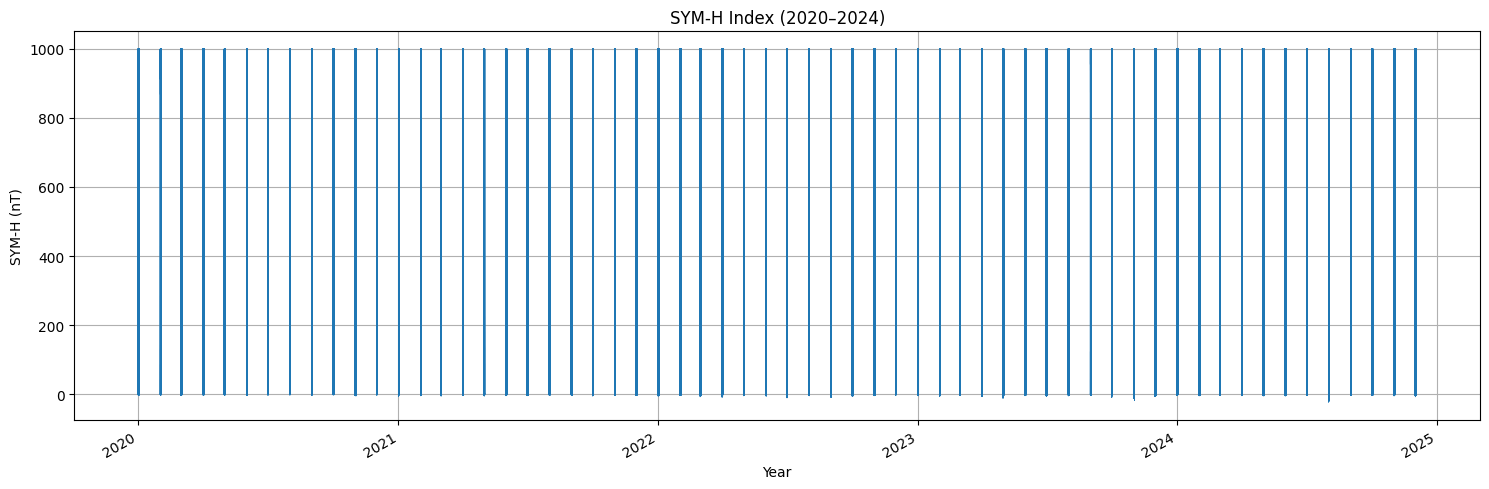

In [18]:
# Plot SYM-H
plt.figure(figsize=(15, 5))
combined_df["SYM-H"].plot(title="SYM-H Index (2020–2024)", linewidth=0.5)
plt.xlabel("Year")
plt.ylabel("SYM-H (nT)")
plt.grid(True)
plt.tight_layout()
plt.show()